Loaded 116224 transitions
TEST 1: RobotState Creation
✓ Created RobotState
  Position: [ 18.53331  -14.101813   0.25    ]
  Quaternion: [0.95539635 0.         0.         0.29532665]
  Base velocity: [ 0.04277913 -0.16840062  0.        ]
  Elevation map shape: (26, 26)
  Quaternion norm: 1.000000 (should be ~1.0)
✓ Quaternion is normalized

TEST 2: Action Creation
✓ Created Action
  Throttle: 0.4591984748840332
  Steering: -0.7612981796264648

TEST 3: Properties
✓ pose_7d shape: (7,) (should be (7,))
✓ base_velocity_6d shape: (6,) (should be (6,))
✓ elevation_map_2d shape: (26, 26) (should be (26, 26))

TEST 4: Tensor Conversion
✓ State tensor shape: torch.Size([720])
  Type: torch.float32
✓ Action tensor shape: torch.Size([2])

TEST 5: Trajectory Creation
✓ Created Trajectory
  Length: 10
  Duration: 1.0s
  Positions shape: (10, 3)
  Orientations shape: (10, 4)
  Poses shape: (10, 7)


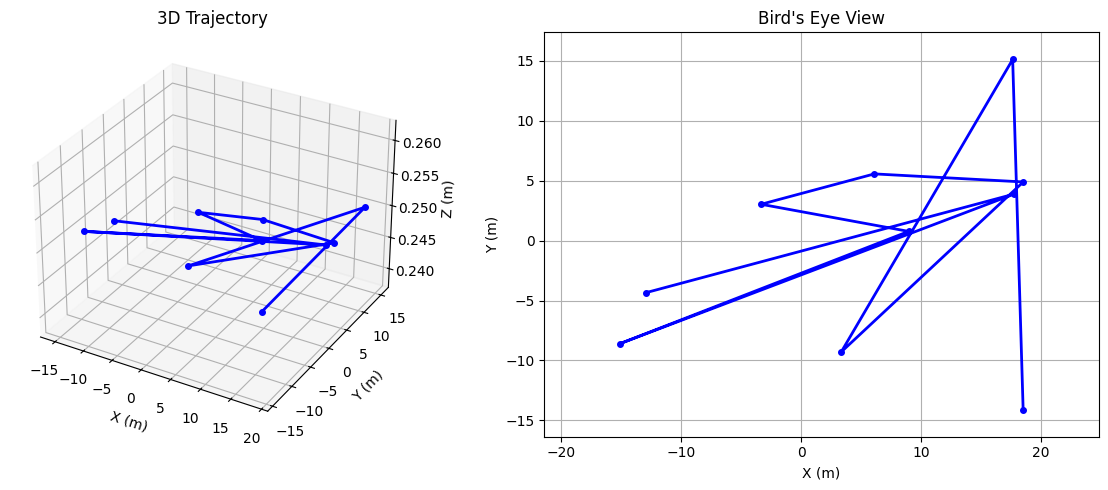


TEST 6: TrainingChunk Creation
✓ Created TrainingChunk
  Episode ID: 0
  Length: 10
  Duration: 1.0s

✓ Converted to tensors:
  bev_map: torch.Size([1, 26, 26])
  initial_state: torch.Size([720])
  initial_pose: torch.Size([7])
  actions: torch.Size([10, 2])
  gt_trajectory: torch.Size([10, 7])

ALL TESTS PASSED! ✓


In [2]:
# Cell 1: Imports
import sys
sys.path.append('..')  # Add parent directory to path

import numpy as np
import h5py
from f1_vault.data import RobotState, Action, Trajectory, TrainingChunk

# Cell 2: Load data
with h5py.File('../data/raw/dynamics_data_0000.h5', 'r') as f:
    states = f['states'][:]
    actions = f['actions'][:]
    next_states = f['next_states'][:]
    episode_ids = f['episode_ids'][:]

print(f"Loaded {len(states)} transitions")

# Cell 3: Test RobotState creation
print("=" * 60)
print("TEST 1: RobotState Creation")
print("=" * 60)

state = RobotState(states[0])

print(f"✓ Created RobotState")
print(f"  Position: {state.root_pos_w}")
print(f"  Quaternion: {state.root_quat_w}")
print(f"  Base velocity: {state.base_lin_vel}")
print(f"  Elevation map shape: {state.elevation_map_2d.shape}")

# Verify quaternion is normalized
quat_norm = np.linalg.norm(state.root_quat_w)
print(f"  Quaternion norm: {quat_norm:.6f} (should be ~1.0)")
assert abs(quat_norm - 1.0) < 0.01, "Quaternion not normalized!"
print("✓ Quaternion is normalized")

# Cell 4: Test Action creation
print("\n" + "=" * 60)
print("TEST 2: Action Creation")
print("=" * 60)

action = Action(actions[0])
print(f"✓ Created Action")
print(f"  Throttle: {action.throttle}")
print(f"  Steering: {action.steering}")

# Cell 5: Test properties
print("\n" + "=" * 60)
print("TEST 3: Properties")
print("=" * 60)

pose = state.pose_7d
print(f"✓ pose_7d shape: {pose.shape} (should be (7,))")
assert pose.shape == (7,), f"Wrong shape: {pose.shape}"

vel = state.base_velocity_6d
print(f"✓ base_velocity_6d shape: {vel.shape} (should be (6,))")
assert vel.shape == (6,), f"Wrong shape: {vel.shape}"

elev = state.elevation_map_2d
print(f"✓ elevation_map_2d shape: {elev.shape} (should be (26, 26))")
assert elev.shape == (26, 26), f"Wrong shape: {elev.shape}"

# Cell 6: Test tensor conversion
print("\n" + "=" * 60)
print("TEST 4: Tensor Conversion")
print("=" * 60)

state_tensor = state.to_tensor()
print(f"✓ State tensor shape: {state_tensor.shape}")
print(f"  Type: {state_tensor.dtype}")

action_tensor = action.to_tensor()
print(f"✓ Action tensor shape: {action_tensor.shape}")

# Cell 7: Test Trajectory creation
print("\n" + "=" * 60)
print("TEST 5: Trajectory Creation")
print("=" * 60)

# Create a short trajectory (10 timesteps)
states_seq = tuple(RobotState(states[i]) for i in range(10))
actions_seq = tuple(Action(actions[i]) for i in range(10))
timesteps = np.arange(10)

traj = Trajectory(
    states=states_seq,
    actions=actions_seq,
    timesteps=timesteps,
    is_terminated=False,
    is_truncated=False
)

print(f"✓ Created Trajectory")
print(f"  Length: {len(traj)}")
print(f"  Duration: {traj.duration}s")
print(f"  Positions shape: {traj.positions.shape}")
print(f"  Orientations shape: {traj.orientations.shape}")
print(f"  Poses shape: {traj.poses_7d.shape}")

# Cell 8: Visualize trajectory
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 5))

# 3D trajectory
ax1 = fig.add_subplot(121, projection='3d')
pos = traj.positions
ax1.plot(pos[:, 0], pos[:, 1], pos[:, 2], 'b-o', linewidth=2, markersize=4)
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Y (m)')
ax1.set_zlabel('Z (m)')
ax1.set_title('3D Trajectory')

# Bird's eye view
ax2 = fig.add_subplot(122)
ax2.plot(pos[:, 0], pos[:, 1], 'b-o', linewidth=2, markersize=4)
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Y (m)')
ax2.set_title('Bird\'s Eye View')
ax2.axis('equal')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Cell 9: Test TrainingChunk
print("\n" + "=" * 60)
print("TEST 6: TrainingChunk Creation")
print("=" * 60)

chunk = TrainingChunk(
    episode_id=int(episode_ids[0]),
    chunk_id=0,
    initial_state=states_seq[0],
    actions=actions_seq,
    gt_trajectory=traj,
    bev_map=states_seq[0].elevation_map_2d
)

print(f"✓ Created TrainingChunk")
print(f"  Episode ID: {chunk.episode_id}")
print(f"  Length: {len(chunk)}")
print(f"  Duration: {chunk.duration}s")

# Test tensor conversion
tensors = chunk.to_tensors()
print(f"\n✓ Converted to tensors:")
for key, value in tensors.items():
    print(f"  {key}: {value.shape}")

print("\n" + "=" * 60)
print("ALL TESTS PASSED! ✓")
print("=" * 60)


INDEX VERIFICATION
Position: [-11.735239 -16.539288   0.25    ]
  X range: -19.80 to 19.81
  Y range: -19.81 to 19.81
  Z range: 0.15 to 0.67

Quaternion norms:
  Mean: 1.000000 (should be ~1.0)
  Std: 0.000000 (should be ~0)
  Min: 1.000000
  Max: 1.000000

Velocity magnitudes:
  Mean: 0.399 m/s
  Max: 9.187 m/s

Elevation map statistics:
  Mean height: inf m


c:\Users\matts\F1-Vault\venv\lib\site-packages\numpy\_core\_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


  Std: nan m
  Range: [-0.001, inf] m


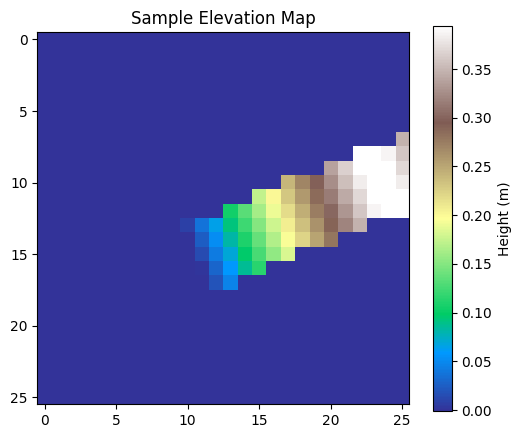

In [3]:
# Cell 10: Verify indices are correct
print("\n" + "=" * 60)
print("INDEX VERIFICATION")
print("=" * 60)

state = RobotState(states[100])  # Use timestep 100 (robot has moved)

# Check 1: Position should be reasonable
print(f"Position: {state.root_pos_w}")
print(f"  X range: {states[:, 0].min():.2f} to {states[:, 0].max():.2f}")
print(f"  Y range: {states[:, 1].min():.2f} to {states[:, 1].max():.2f}")
print(f"  Z range: {states[:, 2].min():.2f} to {states[:, 2].max():.2f}")

# Check 2: Quaternion should be normalized
quat_norms = np.linalg.norm(states[:, 3:7], axis=1)
print(f"\nQuaternion norms:")
print(f"  Mean: {quat_norms.mean():.6f} (should be ~1.0)")
print(f"  Std: {quat_norms.std():.6f} (should be ~0)")
print(f"  Min: {quat_norms.min():.6f}")
print(f"  Max: {quat_norms.max():.6f}")

if quat_norms.mean() < 0.95 or quat_norms.mean() > 1.05:
    print("⚠ WARNING: Quaternions not normalized! Check indices!")

# Check 3: Velocities should be reasonable (< 10 m/s for ground robot)
vel_norms = np.linalg.norm(states[:, 10:13], axis=1)
print(f"\nVelocity magnitudes:")
print(f"  Mean: {vel_norms.mean():.3f} m/s")
print(f"  Max: {vel_norms.max():.3f} m/s")

if vel_norms.max() > 50:
    print("⚠ WARNING: Velocities too high! Check indices!")

# Check 4: Elevation map statistics
elev_maps = states[:, -676:].reshape(-1, 26, 26)
print(f"\nElevation map statistics:")
print(f"  Mean height: {elev_maps.mean():.3f} m")
print(f"  Std: {elev_maps.std():.3f} m")
print(f"  Range: [{elev_maps.min():.3f}, {elev_maps.max():.3f}] m")

# Visualize one elevation map
plt.figure(figsize=(6, 5))
plt.imshow(state.elevation_map_2d, cmap='terrain')
plt.colorbar(label='Height (m)')
plt.title('Sample Elevation Map')
plt.show()